# Mandatory Assignment 02 - Question 2
## Natural Language Processing and Text Analytics (CDSCO1021C)

**Names:** TODO

**Student numbers:**  TODO

## 1. Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# Load dataset
df = pd.read_csv('CyberBullying Comments Dataset.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nClass distribution (CB_Label):\n{df['CB_Label'].value_counts()}")
print(f"\nClass proportions:\n{df['CB_Label'].value_counts(normalize=True).round(3)}")

df.head()

Shape: (11100, 2)

Column types:
Text        object
CB_Label     int64
dtype: object

Missing values:
Text        0
CB_Label    0
dtype: int64

Class distribution (CB_Label):
CB_Label
0    5550
1    5550
Name: count, dtype: int64

Class proportions:
CB_Label
0    0.5
1    0.5
Name: proportion, dtype: float64


,Text,CB_Label
0,damn there is someones nana up here at beach w...,0
1,no kidding! dick clark was a corpse mechanical...,0
2,i read an article on jobros and thought damn w...,0
3,I got one fucking day of sprinkles and now it'...,0
4,I was already listening to Elliott smith and ...,0


The dataset has two columns: `Text` (the tweet) and `CB_Label` (1 = cyberbullying, 0 = not). We check for missing values and class imbalance before proceeding.

### 1.1 Preprocessing and vectorization

In [2]:
# Drop rows with missing text
df = df.dropna(subset=['Text'])

# Preprocessing function
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()                              # lowercase
    text = re.sub(r'[^a-z\s]', '', text)             # keep only letters and spaces
    tokens = word_tokenize(text)                      # tokenize
    tokens = [t for t in tokens if t not in stop_words]  # remove stop words
    return ' '.join(tokens)

df['clean_text'] = df['Text'].apply(preprocess)

# Vectorize using TF-IDF
vectorizer = TfidfVectorizer(max_features=10000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['CB_Label']

print(f"TF-IDF matrix shape: {X.shape}")
print(f"Sample cleaned text: {df['clean_text'].iloc[0]}")

TF-IDF matrix shape: (11100, 10000)
Sample cleaned text: damn someones nana beach one dont think ic steal get quickly tho


Each tweet is lowercased, stripped of non-letter characters, tokenized, and filtered for stop words. We then convert the cleaned text into TF-IDF vectors (capped at 10,000 features) for use as model input.

### 1.2 Train/test split

In [3]:
# 80/20 split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 8880 samples
Test set:     2220 samples


We split 80/20 with stratification so both sets preserve the original class ratio.

## 2. Naive Bayes Classification

Naive Bayes Results
Accuracy:  0.7297
Precision: 0.7520
Recall:    0.6856
F1-score:  0.7172

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.77      0.74      1110
           1       0.75      0.69      0.72      1110

    accuracy                           0.73      2220
   macro avg       0.73      0.73      0.73      2220
weighted avg       0.73      0.73      0.73      2220



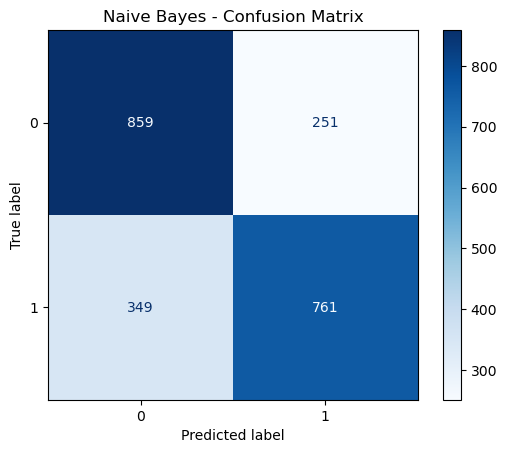

In [4]:
# Train Naive Bayes (MultinomialNB works well with TF-IDF)
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predict on test set
nb_preds = nb_model.predict(X_test)

# Evaluation metrics
print("Naive Bayes Results")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, nb_preds):.4f}")
print(f"Precision: {precision_score(y_test, nb_preds):.4f}")
print(f"Recall:    {recall_score(y_test, nb_preds):.4f}")
print(f"F1-score:  {f1_score(y_test, nb_preds):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, nb_preds)}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, nb_preds, cmap='Blues')
plt.title('Naive Bayes - Confusion Matrix')
plt.show()

We use MultinomialNB, which is the standard Naive Bayes variant for text classification with TF-IDF features. The confusion matrix shows how many cyberbullying and non-cyberbullying tweets were correctly and incorrectly classified.

## 3. Logistic Regression Classification

Logistic Regression Results
Accuracy:  0.7104
Precision: 0.7425
Recall:    0.6441
F1-score:  0.6898

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.78      0.73      1110
           1       0.74      0.64      0.69      1110

    accuracy                           0.71      2220
   macro avg       0.71      0.71      0.71      2220
weighted avg       0.71      0.71      0.71      2220



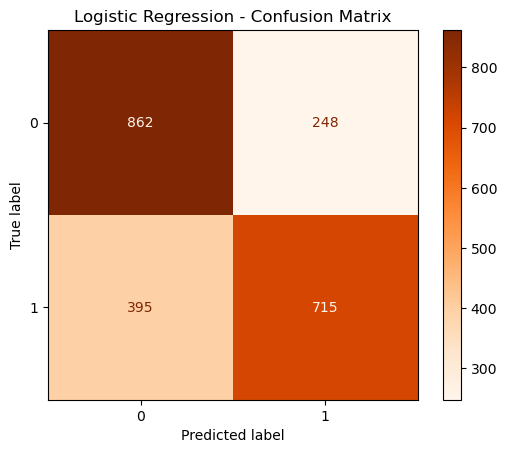

In [5]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict on test set
lr_preds = lr_model.predict(X_test)

# Evaluation metrics
print("Logistic Regression Results")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.4f}")
print(f"Precision: {precision_score(y_test, lr_preds):.4f}")
print(f"Recall:    {recall_score(y_test, lr_preds):.4f}")
print(f"F1-score:  {f1_score(y_test, lr_preds):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, lr_preds)}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, lr_preds, cmap='Oranges')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

Logistic Regression is trained on the same TF-IDF features and evaluated on the same test set, making the comparison with Naive Bayes direct and fair.

## 4. Short Report

   Metric  Naive Bayes  Logistic Regression
 Accuracy       0.7297               0.7104
Precision       0.7520               0.7425
   Recall       0.6856               0.6441
 F1-score       0.7172               0.6898


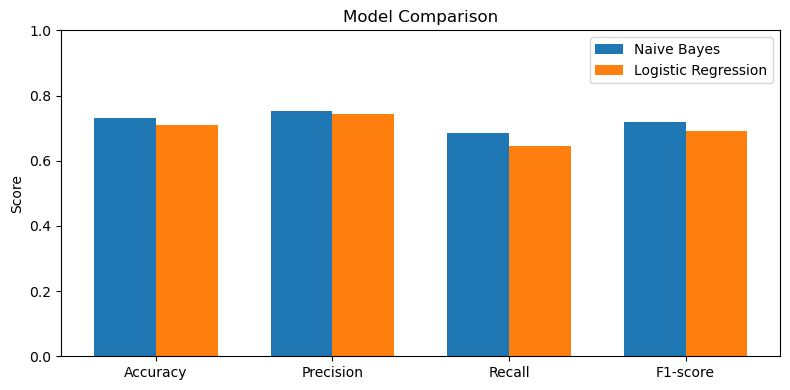

In [6]:
# Side-by-side comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
nb_scores = [
    accuracy_score(y_test, nb_preds),
    precision_score(y_test, nb_preds),
    recall_score(y_test, nb_preds),
    f1_score(y_test, nb_preds),
]
lr_scores = [
    accuracy_score(y_test, lr_preds),
    precision_score(y_test, lr_preds),
    recall_score(y_test, lr_preds),
    f1_score(y_test, lr_preds),
]

comparison = pd.DataFrame({
    'Metric': metrics,
    'Naive Bayes': [round(s, 4) for s in nb_scores],
    'Logistic Regression': [round(s, 4) for s in lr_scores],
})
print(comparison.to_string(index=False))

# Bar chart comparison
x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, nb_scores, width, label='Naive Bayes')
ax.bar(x + width/2, lr_scores, width, label='Logistic Regression')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

### 4.1 Models' comparison (Naive Bayes vs Logistic Regression)

*TODO: Compare the metrics from the table above. Which model performed better overall? Where did each model do well or poorly?*

### 4.2 Advantages and disadvantages (2-3 each, specific to this dataset)

*TODO: Fill in after running the code and seeing the results.*

**Naive Bayes:**
- Advantages: ...
- Disadvantages: ...

**Logistic Regression:**
- Advantages: ...
- Disadvantages: ...

### 4.3 Other important findings

*TODO: Note anything interesting, e.g. impact of class imbalance, effect of preprocessing choices, etc.*